# Trade the 8-K · Does the option chain bend after a corporate headline?

**PolyBridge · Jacob Crainic and Theo Machado · Gator Quant Hacks 2026, Massive Challenge.** Built on the Massive starter
notebook: same endpoints, calendar, put-call-parity spot, five-strategy P&L engine, fixed horizons, expiry buckets and
placebo. The starter's code lives in `polybridge_research/` (each module names the starter section it comes from) so it is
unit-tested.

## Our thesis

PolyBridge starts from one premise: **the listed option chain is the professional price of an event.** In our main-track
study, on 4,561 fresh Polymarket stock markets, pre-registered and run once, the option-implied probability was a more
accurate forecast than the Polymarket price (Brier difference +0.0108, 95% CI +0.0064 to +0.0158), and the gap vanished
where professionals quote both sides. Thin retail books drift from the chain; a deep, dealer-quoted chain should not.

So we use the chain as the ruler, and a market maker's question follows: **where could the ruler itself bend?** Dealers
price an event from what they can see and hedge. Two kinds of 8-K break one of those:

- **H1 · risk that resolves slowly → protective put.** After `material_litigation`, `class_action_filing`,
  `regulatory_investigation`, `cybersecurity_incident`, `goodwill_impairment`, `asset_impairment` or
  `investment_impairment`, dealers mark implied volatility down once the headline passes, but the legal or accounting
  damage resolves over weeks. The chain should over-price the first day and under-price the follow-through, so a put
  bought after the filing is cheap.
- **H2 · demand that is one-sided → cash-secured put.** After `restructuring_plan`, `workforce_reduction`,
  `facility_closure` or `business_line_exit`, holders who must sit through the event buy puts, and dealers charge for
  demand they cannot offset (Gârleanu, Pedersen and Poteshman, 2009). Puts should be over-priced, so selling one earns
  more than on an ordinary day.

Each makes two predictions: a P&L edge for its strategy, and a sign on the parity ratio *R* = |realized move| ÷ implied
move (H1 above ordinary days, H2 below). Requiring both rules out a strategy that is merely long or short volatility in a
busy or calm year. **If the ruler is straight, both come back null with tight bounds**, and a holder can buy or sell
protection at the next close without paying for the headline. If either passes, the chain bends in a predictable place
and the strategy collects it.

**Pre-registration.** [HYPOTHESIS.md](HYPOTHESIS.md) and [HYPOTHESIS_TAGS.md](HYPOTHESIS_TAGS.md) were committed on
2 October 2026 before any 8-K event or option price was fetched. The out-of-sample window was run once after the method
freeze (git tag `method-freeze`). [FORECAST.md](FORECAST.md), our prediction for the out-of-sample and sealed windows,
was committed before either was run.

**Pass rule (fixed before results).** The 97.5% interval of the P&L edge (events minus ordinary days for the same names)
lies above zero at 2 or more of 21 sessions, 42 sessions and expiry, and *R* points the predicted way at those horizons.
Fewer than 2 testable headline horizons is reported as INSUFFICIENT. Entry is conservative: every filing is treated as
public after the close, so the trade enters at the close of the next session.

## How to run (judges)

1. Put `MASSIVE_API_KEY` in the environment or a `.env` file in this folder or a parent. Nothing else is needed.
2. `pip install -r requirements.txt` from this folder (it installs `polybridge_research` in editable mode). Opened outside
   the repo (Colab, a copied `.ipynb`), the first code cell installs the package from GitHub instead.
3. **Sealed window:** set `HOLDOUT_START`, `HOLDOUT_END` and `RUN_HOLDOUT = True` in the configuration cell, as in the
   starter, then run all cells. The last section runs the frozen pipeline on that window for both families and prints our
   committed forecast beside the verdict.

Run-all does the in-sample study, the out-of-sample re-run (`RUN_OOS`), the 2022 fresh year (`RUN_FRESH_2022`) and, when
flipped, the sealed window. From an empty cache expect roughly 10 to 20 minutes on a first run (tens of thousands of option
bars are fetched and cached in `.massive_cache/`); from a warm cache about a minute. Set `RUN_OOS = RUN_FRESH_2022 = False`
to run only the in-sample study and the sealed window.

In [1]:
try:
    import polybridge_research  # noqa: F401
except ImportError:
    %pip install -q "git+https://github.com/theomachado05/polybridge.git#subdirectory=research"

In [2]:
STUDY_START, STUDY_END = "2024-01-01", "2025-12-31"
OOS_START, OOS_END = "2026-01-01", "2026-08-31"
HOLDOUT_START, HOLDOUT_END = "2023-06-01", "2023-08-31"
RUN_HOLDOUT = False

RUN_FRESH_2022 = True
RUN_OOS = True
OOS_LAST_SESSION = "2026-10-02"
MAX_WORKERS = 8

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from polybridge_research.analysis import (decay_table, difference_board, pass_check, robustness_table, sample_placebo,
                                         scoreboard, verdict)
from polybridge_research.atlas import count_variants
from polybridge_research.book import book_table
from polybridge_research.calendar import TradingCalendar
from polybridge_research.config import StudyConfig
from polybridge_research.costs import cost_table
from polybridge_research.evaluate import evaluate
from polybridge_research.massive import MassiveClient, load_api_key
from polybridge_research.pipeline import run_family_study
from polybridge_research.pricing import price_events

for _name in ("STUDY_START", "STUDY_END", "OOS_START", "OOS_END", "HOLDOUT_START", "HOLDOUT_END"):
    pd.Timestamp(globals()[_name])
assert STUDY_START < STUDY_END and OOS_START < OOS_END and HOLDOUT_START < HOLDOUT_END

cfg = StudyConfig(study_start=STUDY_START, study_end=STUDY_END, oos_start=OOS_START, oos_end=OOS_END)
cfg.validate()
START, END = STUDY_START, STUDY_END
LAST_SESSION = "2026-10-02"

In [3]:
from IPython.display import Markdown, display

key = load_api_key(search_from=Path.cwd())
client = MassiveClient(key)
cal = TradingCalendar()
LAST = pd.Timestamp(LAST_SESSION) if LAST_SESSION else cal.last_completed()
FAMILIES = ["hedge", "opportunity"]
HEADS = list(cfg.headline_horizons)
print("Timing mode: conservative (every filing treated as public after the close; frozen for all confirmatory runs)")
print(f"Window {START} -> {END}; last session used for exits {LAST.date()} ({'pinned' if LAST_SESSION else 'today, not pinned'})")


def show(df, title=None):
    if title:
        print(title)
    if df is None or len(df) == 0:
        print("no events in this window")
    else:
        display(df)


def of_family(df, fam):
    if df is None or len(df) == 0 or "family" not in df:
        return pd.DataFrame() if df is None else df.iloc[0:0]
    return df[df["family"] == fam]


def hpos(horizons):
    order = [*cfg.horizons, "exp"]
    return [order.index(h) for h in horizons]


Timing mode: conservative (every filing treated as public after the close; frozen for all confirmatory runs)
Window 2024-01-01 -> 2025-12-31; last session used for exits 2026-10-02 (pinned)


In [4]:
STRATEGY_OF = {"hedge": "protective_put", "opportunity": "cash_secured_put"}


def book_report(st, years, label):
    tab, lists = book_table(st, cfg, STRATEGY_OF, years)
    keep = ["trades", "trades_per_year", "mean_net_pct", "hit_rate", "annual_return_pct", "annual_vol_pct", "sharpe_net",
            "max_drawdown_pct", "worst_trade_pct", "avg_open_positions", "turnover_x_per_year"]
    show(tab[[c for c in keep if c in tab]].round(2),
         f"{label}: the book, net of a 5% premium haircut each way (percent of one trade's stock notional). Ordinary days "
         "are a 120-day sample per family, annualised at the filings' trade rate: compare Sharpe and mean, not trade count or drawdown.")
    fig, ax = plt.subplots(figsize=(7, 3))
    for fam, colr in (("hedge", "tab:red"), ("opportunity", "tab:blue")):
        t = lists[(fam, "filings")]
        if len(t):
            ax.step(pd.to_datetime(t.exit_date), 100 * t.net.cumsum(), where="post", color=colr,
                    label=f"{fam}: {STRATEGY_OF[fam]} ({len(t)} trades)")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("cumulative net P&L, % of one trade"); ax.set_title(f"{label}: equity curve of the registered rules")
    ax.legend(fontsize=8); plt.show()
    return tab, lists

## 1 · In-sample study, 2024-01-01 to 2025-12-31

Events by family, exclusions (cross-family filings are dropped from both tests) and drops before pricing.

In [5]:
study = run_family_study(client, cal, cfg, START, END, LAST, user_agent=None, max_workers=MAX_WORKERS)
ev = study["events"]
if ev.empty:
    print("no events in this window")
else:
    by_year = ev.assign(year=pd.to_datetime(ev["filing_date"]).dt.year).groupby(["family", "year"]).size().unstack(fill_value=0)
    show(by_year, "Events by family and year")
print("Filings excluded because they fit neither family (cross-family or other tags):", len(study["excluded"]))
print("Timing counts:", study["timing_counts"])
dropped = study["dropped"]
if len(dropped):
    show(dropped.groupby("reason").size().rename("n").to_frame(), "Events dropped before pricing, by reason")
else:
    print("no events dropped")


events: 60 events -> 160 priced (event, bucket) pairs; 16 drops


placebo hedge: 120 events -> 318 priced (event, bucket) pairs; 34 drops


placebo opportunity: 120 events -> 313 priced (event, bucket) pairs; 39 drops


Events by family and year


year,2024,2025
family,,
hedge,18,18
opportunity,14,10


Filings excluded because they fit neither family (cross-family or other tags): 5
Timing counts: {'conservative': 60}
Events dropped before pricing, by reason


,n
reason,
1m: ATM pair did not trade on or near the pre-event session,8
2m: ATM pair did not trade on or near the pre-event session,1
2m: no expiry 46-80 days out,5
could not recover spot from the chain (no liquid near-dated pair),2


## 2 · Scoreboards and the placebo gap at every fixed horizon

All five strategies for events and for ordinary days, then the event-minus-placebo edge with its interval.

[hedge] events: mean P&L per $1 of spot (95% CI)


,strategy,horizon,n,mean,ci_lo,ci_hi,median,hit_rate
0,stock,1,34,0.002313,-0.001398,0.006086,0.000107,0.529412
1,stock,2,33,0.000310,-0.010095,0.009436,0.000213,0.545455
2,stock,3,33,-0.000730,-0.020501,0.015305,0.008331,0.575758
3,stock,5,32,-0.004668,-0.027779,0.017570,-0.003741,0.437500
4,stock,10,32,0.002206,-0.020183,0.025578,0.002736,0.562500
5,stock,21,32,0.024358,-0.002947,0.050590,0.042001,0.656250
6,stock,42,30,0.048052,-0.001239,0.095746,0.038274,0.566667
7,stock,63,28,0.076765,0.018201,0.131236,0.049063,0.714286
8,stock,exp,31,0.081386,0.028975,0.135561,0.055177,0.677419
9,long_call,1,34,0.001139,-0.001127,0.003399,0.000000,0.441176


[hedge] placebo


,strategy,horizon,n,mean,ci_lo,ci_hi,median,hit_rate
0,stock,1,112,0.004471,0.001697,0.007192,0.001786,0.625000
1,stock,2,111,0.004316,0.000364,0.008291,0.000350,0.531532
2,stock,3,111,0.005335,-0.000229,0.011070,0.004561,0.540541
3,stock,5,112,0.005076,-0.003210,0.012453,0.002594,0.517857
4,stock,10,108,0.009518,-0.001605,0.019894,0.013812,0.583333
5,stock,21,109,0.026732,0.010291,0.043423,0.021175,0.633028
6,stock,42,107,0.047697,0.023022,0.073079,0.048879,0.663551
7,stock,63,102,0.046151,0.018097,0.076135,0.024210,0.568627
8,stock,exp,105,0.066407,0.031841,0.102658,0.043419,0.590476
9,long_call,1,113,0.002566,0.000890,0.004463,0.000442,0.513274


[hedge] events minus placebo (97.5% CI)


...

,strategy,horizon,n,mean,ci_lo,ci_hi,median,hit_rate
0,stock,1,24,-0.003118,-0.009712,0.003078,-0.003075,0.416667
1,stock,2,24,-0.000245,-0.009092,0.008348,0.000070,0.500000
2,stock,3,24,-0.000608,-0.012848,0.011750,0.001477,0.541667
3,stock,5,24,0.005394,-0.006201,0.016612,0.007246,0.541667
4,stock,10,24,0.024256,-0.000052,0.051988,0.005870,0.541667
5,stock,21,24,0.026065,0.000796,0.053161,0.003388,0.541667
6,stock,42,24,0.038251,0.002602,0.074884,0.016014,0.583333
7,stock,63,24,0.097056,0.043279,0.159666,0.047071,0.625000
8,stock,exp,23,0.098510,0.049740,0.151976,0.088982,0.739130
9,long_call,1,24,-0.001243,-0.004980,0.002593,-0.000776,0.500000


[opportunity] placebo


,strategy,horizon,n,mean,ci_lo,ci_hi,median,hit_rate
0,stock,1,113,0.003640,0.001039,0.006063,0.000473,0.548673
1,stock,2,114,0.004849,0.000787,0.008822,0.001267,0.535088
2,stock,3,114,0.006428,0.000780,0.011874,-0.000668,0.473684
3,stock,5,114,0.010434,0.002785,0.018258,0.007295,0.578947
4,stock,10,113,0.018139,0.008453,0.027451,0.013973,0.672566
5,stock,21,109,0.030673,0.016798,0.045277,0.020413,0.651376
6,stock,42,108,0.048870,0.031137,0.065721,0.049596,0.712963
7,stock,63,110,0.048166,0.028629,0.067724,0.046713,0.672727
8,stock,exp,106,0.058608,0.034402,0.084245,0.056504,0.679245
9,long_call,1,114,0.001766,0.000185,0.003345,-0.000171,0.464912


[opportunity] events minus placebo (97.5% CI)


,strategy,horizon,n_a,n_b,mean_a,mean_b,difference,ci_lo,ci_hi,p_value
0,stock,1,24,113,-0.003118,0.003640,-0.006758,-0.014784,0.001037,0.0515
1,stock,2,24,114,-0.000245,0.004849,-0.005094,-0.016051,0.005391,0.2940
2,stock,3,24,114,-0.000608,0.006428,-0.007036,-0.023358,0.008127,0.3160
3,stock,5,24,114,0.005394,0.010434,-0.005040,-0.021099,0.010677,0.4840
4,stock,10,24,113,0.024256,0.018139,0.006117,-0.021889,0.039628,0.6870
5,stock,21,24,109,0.026065,0.030673,-0.004608,-0.038532,0.032448,0.7340
6,stock,42,24,108,0.038251,0.048870,-0.010618,-0.054937,0.036575,0.5725
7,stock,63,24,110,0.097056,0.048166,0.048890,-0.017438,0.123014,0.1275
8,stock,exp,23,106,0.098510,0.058608,0.039902,-0.020418,0.105189,0.1610
9,long_call,1,24,114,-0.001243,0.001766,-0.003009,-0.007600,0.001725,0.1520


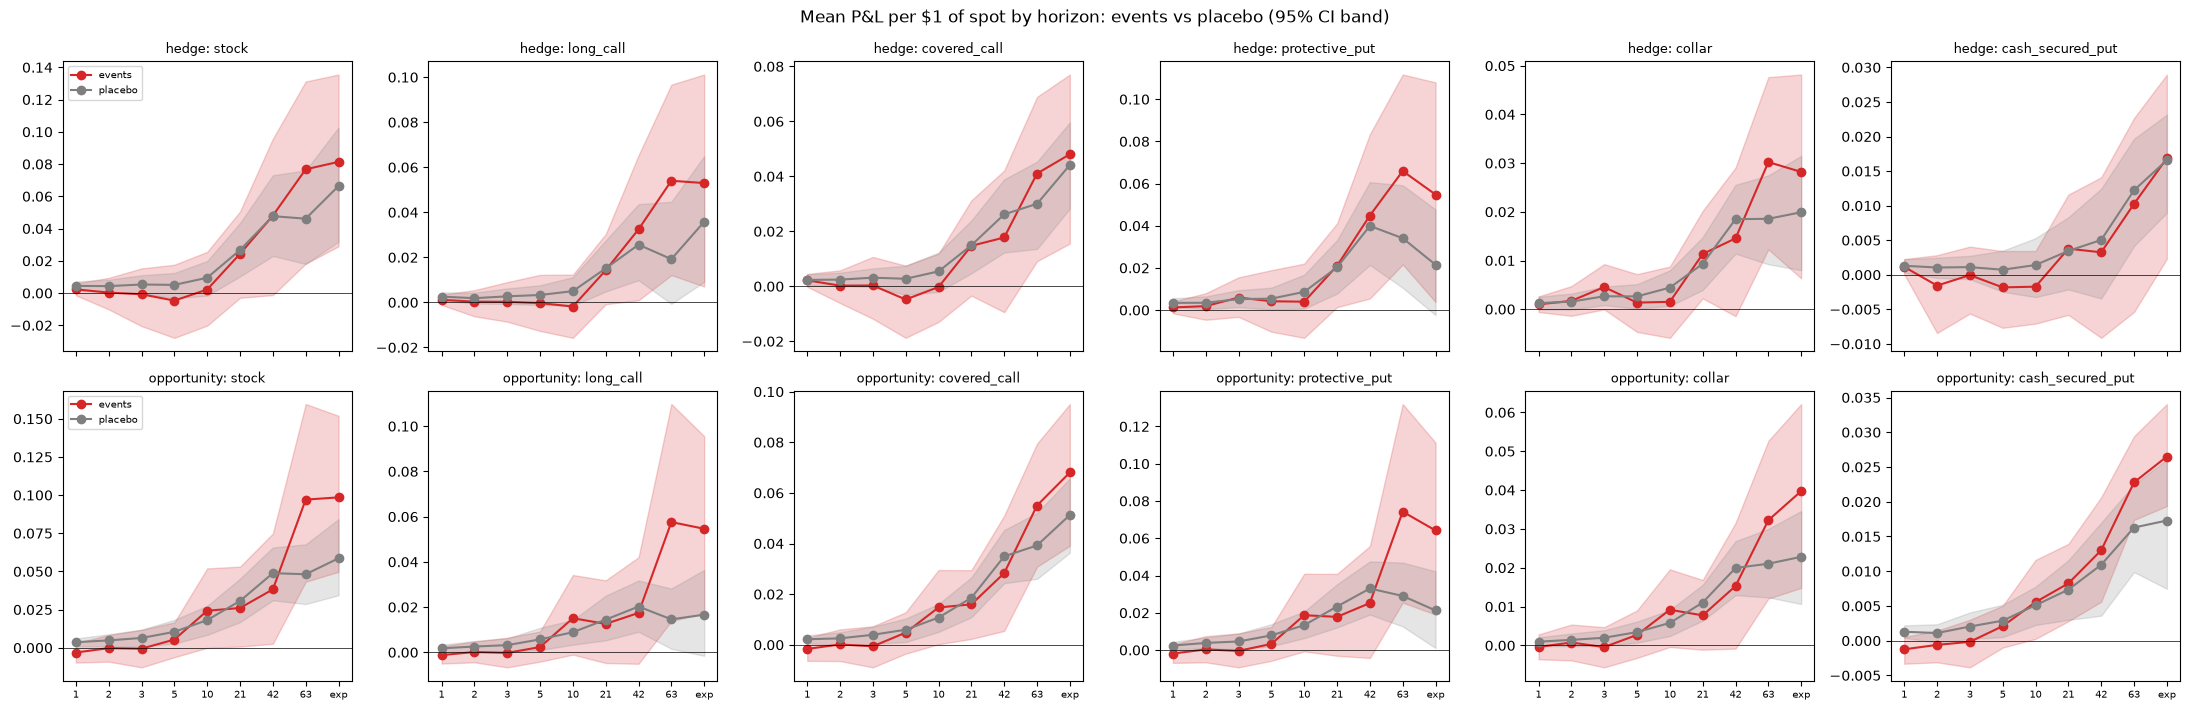

In [6]:
res, pl = study["results"], study["placebo_results"]
rows_f = [f for f in FAMILIES if len(of_family(res, f))]
if not rows_f:
    print("no events in this window")
else:
    fig, axes = plt.subplots(len(rows_f), 6, figsize=(22, 3.6 * len(rows_f)), squeeze=False, sharex=True)
    for i, fam in enumerate(rows_f):
        ev_r, pl_r = of_family(res, fam), of_family(pl, fam)
        sb_e = scoreboard(ev_r, cfg)
        show(sb_e, f"[{fam}] events: mean P&L per $1 of spot (95% CI)")
        if len(pl_r):
            sb_p = scoreboard(pl_r, cfg)
            show(sb_p, f"[{fam}] placebo")
            show(difference_board(ev_r, pl_r, cfg, level=cfg.confirmatory_level),
                 f"[{fam}] events minus placebo (97.5% CI)")
        else:
            sb_p = None
            print(f"[{fam}] no placebo days priced")
        for j, s in enumerate(sb_e["strategy"].unique()):
            ax = axes[i][j]
            for sb, label, colr in ((sb_e, "events", "tab:red"), (sb_p, "placebo", "tab:gray")):
                if sb is None:
                    continue
                d = sb[sb.strategy == s].dropna(subset=["mean"])
                if d.empty:
                    continue
                x = hpos(d["horizon"])
                ax.plot(x, d["mean"], marker="o", color=colr, label=label)
                ax.fill_between(x, d["ci_lo"], d["ci_hi"], color=colr, alpha=0.2)
            ax.axhline(0, color="k", lw=0.5)
            ax.set_title(f"{fam}: {s}", fontsize=9)
            ax.set_xticks(range(len(cfg.horizons) + 1))
            ax.set_xticklabels([*map(str, cfg.horizons), "exp"], fontsize=7)
        axes[i][0].legend(fontsize=7)
    fig.suptitle("Mean P&L per $1 of spot by horizon: events vs placebo (95% CI band)")
    plt.tight_layout()
    plt.show()


**Table 1 of the write-up** (the registered strategy alone; the board above bootstraps all strategies with one generator, so its intervals differ in the last digit).

In [7]:
for fam in FAMILIES:
    chk = study["checks"].get(fam)
    r_e, r_p = of_family(study["results"], fam), of_family(study["placebo_results"], fam)
    if chk is None or not len(r_e) or not len(r_p):
        print(f"[{fam}] no events or no placebo in this window")
        continue
    show(difference_board(r_e, r_p, cfg, level=cfg.confirmatory_level, strategies=[chk["strategy"]]),
         f"[{fam}] {chk['strategy']}: events minus ordinary days at every fixed horizon (97.5% CI)")

[hedge] protective_put: events minus ordinary days at every fixed horizon (97.5% CI)


,strategy,horizon,n_a,n_b,mean_a,mean_b,difference,ci_lo,ci_hi,p_value
0,protective_put,1,33,110,0.001234,0.003420,-0.002186,-0.006300,0.001872,0.2250
1,protective_put,2,32,110,0.001880,0.003469,-0.001588,-0.009956,0.005873,0.6710
2,protective_put,3,32,109,0.005954,0.005197,0.000757,-0.010883,0.011818,0.8770
3,protective_put,5,31,109,0.004185,0.005437,-0.001252,-0.019035,0.017517,0.8360
4,protective_put,10,32,106,0.003982,0.008628,-0.004647,-0.025604,0.016470,0.5975
5,protective_put,21,32,106,0.020973,0.020272,0.000700,-0.026955,0.029074,0.9820
6,protective_put,42,30,104,0.044837,0.039928,0.004909,-0.045143,0.057691,0.8485
7,protective_put,63,28,99,0.065947,0.034097,0.031850,-0.026508,0.091384,0.2215
8,protective_put,exp,28,95,0.054812,0.021521,0.033292,-0.030070,0.101245,0.2670


[opportunity] cash_secured_put: events minus ordinary days at every fixed horizon (97.5% CI)


,strategy,horizon,n_a,n_b,mean_a,mean_b,difference,ci_lo,ci_hi,p_value
0,cash_secured_put,1,24,111,-0.001244,0.001287,-0.002531,-0.005243,-0.000158,0.0175
1,cash_secured_put,2,24,110,-0.000607,0.001100,-0.001707,-0.005105,0.001215,0.2045
2,cash_secured_put,3,24,110,-0.000166,0.002036,-0.002203,-0.007295,0.002092,0.2670
3,cash_secured_put,5,24,113,0.002090,0.002880,-0.000790,-0.005272,0.003337,0.6895
4,cash_secured_put,10,24,113,0.005548,0.005098,0.000450,-0.006170,0.007752,0.9150
5,cash_secured_put,21,24,113,0.008246,0.007347,0.000899,-0.006821,0.008896,0.8485
6,cash_secured_put,42,24,111,0.013009,0.010924,0.002086,-0.009010,0.013602,0.6940
7,cash_secured_put,63,24,107,0.022781,0.016283,0.006498,-0.003229,0.016947,0.1500
8,cash_secured_put,exp,23,99,0.026500,0.017292,0.009208,-0.003630,0.023427,0.1185


## 3 · The pre-registered pass check

In [8]:
for fam in FAMILIES:
    chk = study["checks"].get(fam)
    if chk is None:
        print(f"{fam}: no events in this window")
        continue
    pnl, ratio = chk["pnl"], chk["ratio"]
    if pnl.empty:
        print(f"{fam}: no headline horizons available in this window")
    else:
        t = pnl[["horizon", "n_a", "n_b", "difference", "ci_lo", "ci_hi"]].rename(
            columns={"n_a": "n_events", "n_b": "n_placebo", "difference": "pnl_edge", "ci_lo": "pnl_ci_lo", "ci_hi": "pnl_ci_hi"})
        t = t.merge(ratio[["horizon", "difference"]].rename(columns={"difference": "ratio_diff"}), on="horizon", how="left")
        t["pnl_ok"] = t["horizon"].isin(chk["horizons_pnl_ok"])
        t["ratio_ok"] = t["horizon"].isin(chk["horizons_ratio_ok"])
        show(t.set_index("horizon"), f"{fam} ({chk['strategy']}): events minus placebo at the headline horizons")
    display(Markdown(f"**{fam.upper()}: {verdict(chk)}**. INSUFFICIENT means fewer than 2 headline horizons had the 5 events a CI needs. PASS rule: the 97.5% CI of the P&L edge (events minus ordinary days) is entirely above 0, "
                     "and the price-gap ratio points the predicted way (H1 above ordinary days, H2 below), "
                     "at 2 or more of 21, 42 and expiry."))


hedge (protective_put): events minus placebo at the headline horizons


,n_events,n_placebo,pnl_edge,pnl_ci_lo,pnl_ci_hi,ratio_diff,pnl_ok,ratio_ok
horizon,,,,,,,,
21,32,106,0.000700,-0.026955,0.029074,0.018708,False,True
42,30,104,0.004909,-0.045143,0.057691,0.208741,False,True
exp,28,95,0.033292,-0.030070,0.101245,0.121141,False,True


**HEDGE: NULL**. INSUFFICIENT means fewer than 2 headline horizons had the 5 events a CI needs. PASS rule: the 97.5% CI of the P&L edge (events minus ordinary days) is entirely above 0, and the price-gap ratio points the predicted way (H1 above ordinary days, H2 below), at 2 or more of 21, 42 and expiry.

opportunity (cash_secured_put): events minus placebo at the headline horizons


,n_events,n_placebo,pnl_edge,pnl_ci_lo,pnl_ci_hi,ratio_diff,pnl_ok,ratio_ok
horizon,,,,,,,,
21,24,113,0.000899,-0.006821,0.008896,-0.171330,False,True
42,24,111,0.002086,-0.009010,0.013602,-0.094962,False,True
exp,23,99,0.009208,-0.003630,0.023427,0.184968,False,False


**OPPORTUNITY: NULL**. INSUFFICIENT means fewer than 2 headline horizons had the 5 events a CI needs. PASS rule: the 97.5% CI of the P&L edge (events minus ordinary days) is entirely above 0, and the price-gap ratio points the predicted way (H1 above ordinary days, H2 below), at 2 or more of 21, 42 and expiry.

**Reading, in-sample 2024–2025 (the committed run; a judge's window prints its own numbers above).** Both hypotheses are
**NULL** in-sample, while on a fresh year no study had touched (2022, section 9) H1 met both pass conditions at 21 sessions,
+4.30% of the stock price over ordinary days [+0.54, +7.93] on 12 events, but not at 42 sessions or expiry. In-sample no
headline interval excludes zero: H1's protective-put edge is +0.07% of the stock price at 21 sessions
[−2.70, +2.91], +0.49% at 42 and +3.33% at expiry; H2's cash-secured-put edge is +0.09% [−0.68, +0.89], +0.21% and +0.92%.
*R* did move the predicted way at all three headline horizons for H1 and at 21 and 42 for H2, so the direction of each
mechanism shows up, but not its size. **What the nulls bound:** the chain did not under-price post-headline protection by
more than about 3% of the stock price (H1), nor over-price restructuring puts by more than about 0.9% (H2).

## 4 · Robustness (reported next to the pass rule, never instead of it)

In [9]:
for fam in FAMILIES:
    chk = study["checks"].get(fam)
    if chk is None:
        continue
    rob = robustness_table(of_family(study["results"], fam), of_family(study["placebo_results"], fam), fam, cfg)
    show(rob.set_index(["check", "horizon"]),
         f"[{fam}] robustness, 97.5% CIs (reported next to the pass rule, never instead of it): company-clustered bootstrap"
         + ("; put leg only = protective put minus stock, the put's own edge" if fam == "hedge" else ""))


[hedge] robustness, 97.5% CIs (reported next to the pass rule, never instead of it): company-clustered bootstrap; put leg only = protective put minus stock, the put's own edge


measure  n_events  n_placebo  \
check                           horizon                                        
pre-registered (iid)            21       protective_put        32        106   
                                42       protective_put        30        104   
                                exp      protective_put        28         95   
company-clustered               21       protective_put        32        106   
                                42       protective_put        30        104   
                                exp      protective_put        28         95   
put leg only (iid)              21              put_leg        32        106   
                                42              put_leg        30        104   
                                exp             put_leg        28         95   
put leg only, company-clustered 21              put_leg        32        106   
                                42              put_leg        30        104   
                                exp             put_leg        28         95   

                                             edge     ci_lo     ci_hi  
check                           horizon                                
pre-registered (iid)            21       0.000700 -0.026955  0.029074  
                                42       0.004909 -0.045143  0.057691  
                                exp      0.033292 -0.030070  0.101245  
company-clustered               21       0.000700 -0.027440  0.027221  
                                42       0.004909 -0.046442  0.053376  
                                exp      0.033292 -0.051889  0.121915  
put leg only (iid)              21       0.000699 -0.010683  0.013625  
                                42       0.003103 -0.013523  0.020778  
                                exp      0.000626 -0.015575  0.019164  
put leg only, company-clustered 21       0.000699 -0.009674  0.013426  
                                42       0.003103 -0.013911  0.022624  
                                exp      0.000626 -0.016350  0.021566

[opportunity] robustness, 97.5% CIs (reported next to the pass rule, never instead of it): company-clustered bootstrap


measure  n_events  n_placebo      edge  \
check                horizon                                                    
pre-registered (iid) 21       cash_secured_put        24        113  0.000899   
                     42       cash_secured_put        24        111  0.002086   
                     exp      cash_secured_put        23         99  0.009208   
company-clustered    21       cash_secured_put        24        113  0.000899   
                     42       cash_secured_put        24        111  0.002086   
                     exp      cash_secured_put        23         99  0.009208   

                                 ci_lo     ci_hi  
check                horizon                      
pre-registered (iid) 21      -0.006821  0.008896  
                     42      -0.009010  0.013602  
                     exp     -0.003630  0.023427  
company-clustered    21      -0.007650  0.008879  
                     42      -0.010807  0.016409  
                     exp     -0.004084  0.024007

## 5 · The yardstick: parity decay (|realized| ÷ implied move)

Entry on the pre-event session, so this is a statement about pricing, not a trade.

[hedge] parity decay, events (ratio = realized / priced, entry on the pre-event session)


,n,mean_ratio,ci_lo,ci_hi,median_ratio,share_above_1
horizon,,,,,,
1,34,0.683312,0.448893,1.018529,0.514103,0.147059
2,33,0.905665,0.641873,1.207374,0.765104,0.303030
3,33,1.153317,0.785212,1.571784,0.701471,0.333333
5,32,1.216864,0.849637,1.617544,1.007921,0.531250
10,32,1.038309,0.775824,1.332683,1.003516,0.500000
21,32,1.113175,0.865999,1.372515,0.979587,0.500000
42,30,1.358990,1.026337,1.679193,1.269302,0.566667
63,28,1.194339,0.868341,1.535437,1.052854,0.500000
exp,31,1.181312,0.877408,1.489159,0.860350,0.451613


[hedge] parity decay, placebo


,n,mean_ratio,ci_lo,ci_hi,median_ratio,share_above_1
horizon,,,,,,
1,112,0.991045,0.833651,1.160335,0.858040,0.401786
2,111,0.915599,0.775919,1.073147,0.669037,0.378378
3,111,0.992280,0.842999,1.157111,0.739393,0.396396
5,113,1.009225,0.850163,1.186608,0.727455,0.389381
10,109,1.052433,0.899023,1.213637,0.845943,0.431193
21,110,1.094467,0.940269,1.256017,0.865500,0.445455
42,107,1.150248,0.995480,1.315607,0.913931,0.457944
63,102,1.006586,0.849545,1.173752,0.789041,0.352941
exp,106,1.060171,0.897216,1.231771,0.891953,0.415094


[opportunity] parity decay, events (ratio = realized / priced, entry on the pre-event session)


,n,mean_ratio,ci_lo,ci_hi,median_ratio,share_above_1
horizon,,,,,,
1,24,1.031638,0.619230,1.518998,0.555478,0.375000
2,24,0.994150,0.641404,1.390269,0.691690,0.375000
3,24,1.077791,0.752854,1.463975,0.981292,0.500000
5,24,0.867519,0.624725,1.155255,0.755449,0.333333
10,24,0.985181,0.604670,1.441108,0.682104,0.333333
21,24,0.772299,0.447205,1.126252,0.490158,0.208333
42,24,0.914556,0.663605,1.200216,0.814534,0.375000
63,24,1.109252,0.750411,1.494363,0.828877,0.500000
exp,23,1.063450,0.764973,1.375502,0.729894,0.478261


[opportunity] parity decay, placebo


,n,mean_ratio,ci_lo,ci_hi,median_ratio,share_above_1
horizon,,,,,,
1,113,0.860234,0.729698,0.989249,0.626496,0.300885
2,114,0.947534,0.808069,1.089341,0.823477,0.412281
3,114,0.923568,0.805399,1.052550,0.777291,0.403509
5,114,1.010880,0.857521,1.166912,0.831965,0.421053
10,113,0.944700,0.812230,1.079357,0.763149,0.424779
21,109,0.943629,0.808852,1.092125,0.751996,0.385321
42,108,1.009518,0.883168,1.132316,0.906232,0.453704
63,110,0.922082,0.802901,1.045943,0.856682,0.363636
exp,106,0.878482,0.752766,1.011284,0.695724,0.330189


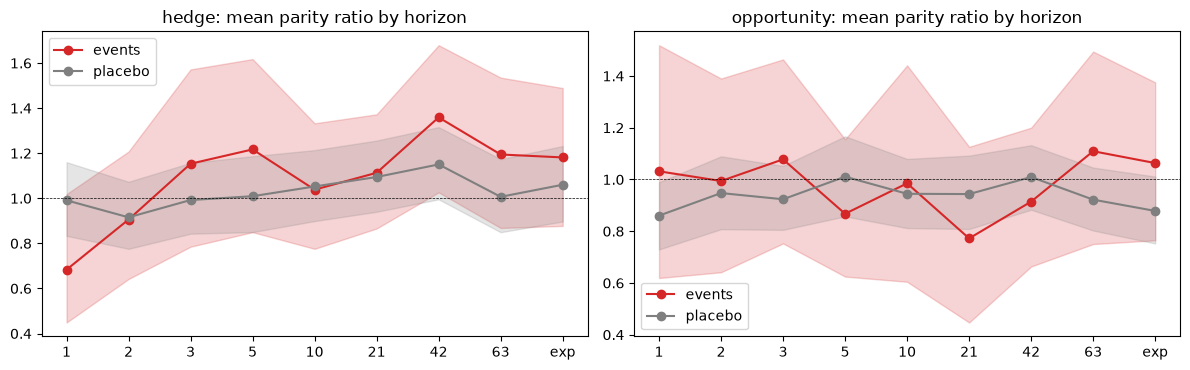

In [10]:
decay = {}
for fam in FAMILIES:
    de = decay_table(of_family(study["results"], fam), cfg)
    dp = decay_table(of_family(study["placebo_results"], fam), cfg)
    decay[fam] = (de, dp)
    show(de, f"[{fam}] parity decay, events (ratio = realized / priced, entry on the pre-event session)")
    show(dp, f"[{fam}] parity decay, placebo")
if all(de.empty for de, _ in decay.values()):
    print("no events in this window")
else:
    fig, axes = plt.subplots(1, len(FAMILIES), figsize=(12, 3.8), squeeze=False)
    for ax, fam in zip(axes[0], FAMILIES):
        for tbl, label, colr in ((decay[fam][0], "events", "tab:red"), (decay[fam][1], "placebo", "tab:gray")):
            d = tbl.dropna(subset=["mean_ratio"])
            if d.empty:
                continue
            x = hpos(d.index)
            ax.plot(x, d["mean_ratio"], marker="o", color=colr, label=label)
            ax.fill_between(x, d["ci_lo"], d["ci_hi"], color=colr, alpha=0.2)
        ax.axhline(1, color="k", lw=0.5, ls="--")
        ax.set_title(f"{fam}: mean parity ratio by horizon")
        ax.set_xticks(range(len(cfg.horizons) + 1))
        ax.set_xticklabels([*map(str, cfg.horizons), "exp"])
        ax.legend()
    plt.tight_layout()
    plt.show()


**Reading: the shape of the ruler.** For H1 the chain priced the first session generously and the follow-through cheaply,
as H1 says: *R* is 0.68 one session after the filing against 0.99 on ordinary days, and 1.36 at 42 sessions against 1.15.
Both gaps sit inside the events' 95% band, so with about 30 events the bend is not distinguishable from a straight ruler.
H2 hugs the ordinary-day line at every horizon (0.77 to 1.11 against 0.86 to 1.01).

## 6 · Parameter sensitivity

The starter's grid: expiry bucket × entry session × OTM distance, at 21 sessions.

In [11]:
from polybridge_research.schema import STRATEGY_FOR_FAMILY, Family

for fam in FAMILIES:
    strat = STRATEGY_FOR_FAMILY[Family(fam)]
    r = of_family(study["results"], fam)
    r = r[r["horizon"] == 21] if len(r) else r
    if len(r):
        grid = r.groupby(["bucket", "entry", "otm"])[strat].agg(n="count", mean_pnl="mean")
        show(grid, f"[{fam}] {strat}: mean P&L at h=21 by bucket x entry x OTM (the starter's grid; entry 'pre' is a pricing statement, not a trade)")
    else:
        print(f"[{fam}] no events in this window")
print("Variants in this sensitivity grid (one tag):", count_variants(cfg))


[hedge] protective_put: mean P&L at h=21 by bucket x entry x OTM (the starter's grid; entry 'pre' is a pricing statement, not a trade)


n  mean_pnl
bucket entry otm               
1m     post  0.03  10  0.019216
             0.05  10  0.014809
             0.10   8  0.010223
       pre   0.03  10  0.018852
             0.05  10  0.013047
             0.10   8  0.014217
2m     post  0.03  30  0.018456
             0.05  28  0.011006
             0.10  29  0.018377
       pre   0.03  29  0.016757
             0.05  28  0.010160
             0.10  29  0.018287
3-6m   post  0.03  32  0.019658
             0.05  32  0.020973
             0.10  30  0.025400
       pre   0.03  31  0.018805
             0.05  31  0.020295
             0.10  31  0.024934

[opportunity] cash_secured_put: mean P&L at h=21 by bucket x entry x OTM (the starter's grid; entry 'pre' is a pricing statement, not a trade)


n  mean_pnl
bucket entry otm               
1m     post  0.03   8  0.018976
             0.05   8  0.012727
             0.10   8  0.006629
       pre   0.03   8  0.018070
             0.05   8  0.012531
             0.10   8  0.006671
2m     post  0.03  20  0.011821
             0.05  20  0.010238
             0.10  19  0.005450
       pre   0.03  20  0.011715
             0.05  20  0.009845
             0.10  19  0.005687
3-6m   post  0.03  24  0.008944
             0.05  24  0.008246
             0.10  24  0.005913
       pre   0.03  24  0.009232
             0.05  23  0.007670
             0.10  24  0.005874

Variants in this sensitivity grid (one tag): 810


**Reading.** At 21 sessions with the tradeable entry, the H2 edge is positive in 9 of 9 cells of expiry bucket × OTM
distance (+0.08% to +1.24%) and H1 in 7 of 9 (−0.67% to +0.68%). The cells share events, so this shows a stable sign, not
nine results. By category (the exploratory per-tag atlas, at most 15 events a tag against a shared placebo), no H1 tag has
an interval above zero; `restructuring_plan` × cash-secured put is positive at 21, 42 sessions and expiry (+2.57%
[+0.95, +4.51] at expiry, 14 events, q = 0.014). That is a lead for a new pre-registered test, not a result.

## 7 · Trade specification: costs, liquidity, capacity

A 5% premium haircut each way at 1× and 2×, and real half-spreads where quotes exist; median leg volume on the entry day.

In [12]:
from polybridge_research.costs import cost_summary

cost_summ = []
QUOTES_OK = True
for fam in FAMILIES:
    strat = STRATEGY_FOR_FAMILY[Family(fam)]
    res_f = of_family(study["results"], fam)
    pl_f = of_family(study["placebo_results"], fam)
    priced_f = [p for p in study["priced"] if str(getattr(p.family, "value", p.family)) == fam]
    pl_priced_f = [p for p in study["placebo_priced"] if str(getattr(p.family, "value", p.family)) == fam]
    for h in (21, 42, "exp"):
        if res_f.empty or not priced_f:
            print(f"[{fam}] h={h}: no events in this window")
            continue
        ct = None
        if QUOTES_OK:
            try:
                ct = cost_table(res_f, priced_f, strat, h, cfg, client=client)
            except Exception as e:
                QUOTES_OK = False
                print(f"Options quotes unavailable on this key ({type(e).__name__}: {e}); spread cost not computed (haircut costs shown).")
        if ct is None:
            ct = cost_table(res_f, priced_f, strat, h, cfg, client=None)
        if ct.empty:
            print(f"[{fam}] h={h}: no events in this window")
            continue
        ct_pl = cost_table(pl_f, pl_priced_f, strat, h, cfg, client=None) if len(pl_f) and pl_priced_f else None
        cost_summ.append({"family": fam, "strategy": strat, "horizon": h, **cost_summary(ct, ct_pl)})
if cost_summ:
    show(pd.DataFrame(cost_summ).set_index(["family", "horizon"]),
         "Costs: mean P&L per $1 of spot. *_paired columns use only rows with both gross and spread (one common sample); "
         "net_haircut_Nx = net of the 5% premium haircut at Nx; net_edge_Nx = events minus placebo, both net of the haircut")


Costs: mean P&L per $1 of spot. *_paired columns use only rows with both gross and spread (one common sample); net_haircut_Nx = net of the 5% premium haircut at Nx; net_edge_Nx = events minus placebo, both net of the haircut


strategy   n  n_gross  n_paired  gross_paired  \
family      horizon                                                          
hedge       21         protective_put  34       32        32      0.020973   
            42         protective_put  34       30        28      0.029227   
            exp        protective_put  34       28         6     -0.093365   
opportunity 21       cash_secured_put  24       24        24      0.008246   
            42       cash_secured_put  24       24        24      0.013009   
            exp      cash_secured_put  24       23         2      0.002252   

                     spread_cost_paired  net_spread_paired     gross  \
family      horizon                                                    
hedge       21                 0.002565           0.018407  0.020973   
            42                 0.001880           0.027347  0.044837   
            exp                0.006078          -0.099442  0.054812   
opportunity 21                 0.002885           0.005361  0.008246   
            42                 0.002598           0.010411  0.013009   
            exp                0.003705          -0.001453  0.026500   

                     median_leg_volume  net_haircut_1x  n_placebo_1x  \
family      horizon                                                    
hedge       21                    33.5        0.018095           106   
            42                    33.5        0.041899           104   
            exp                   33.5        0.051805            95   
opportunity 21                    48.5        0.005405           113   
            42                    48.5        0.010169           111   
            exp                   48.5        0.023604            99   

                     net_edge_1x  net_haircut_2x  n_placebo_2x  net_edge_2x  
family      horizon                                                          
hedge       21          0.001108        0.015218           106     0.001516  
            42          0.005183        0.038962           104     0.005458  
            exp         0.033569        0.048797            95     0.033847  
opportunity 21          0.001132        0.002564           113     0.001365  
            42          0.002372        0.007328           111     0.002657  
            exp         0.009451        0.020708            99     0.009694

**Reading, in basis points.** A 5% premium haircut each way costs 28–29 bp of the stock price at 21 sessions; real
half-spreads where quotes exist are 26–29 bp. Net of the haircut the edge over ordinary days is about +11 bp for both
families, inside the noise. The median put traded 34 (H1) and 49 (H2) contracts on the entry day: at 10% participation a
desk fills 3 to 5 contracts an event, about $0.1 million of stock notional, on roughly 1.3 H1 and 1.0 H2 events a month.
Even a real edge would be a cost statement for a hedger, not a strategy with capacity.

## 7b · The rules run as a book: equity curve, drawdown, turnover, Sharpe

One trade per filing at the registered cell (3–6 month expiry, entry at the close after the filing, 5% OTM, held
21 sessions), each $1 of stock notional, net of the 5% premium haircut each way. Each trade books on its exit date. Holds
overlap, so Sharpe is per trade annualised by the window's trade rate, not a daily-NAV figure. Turnover: each position
lives 21 sessions, so capital turns over 12 times a year, and the book holds on average `avg_open_positions` trades.

In-sample 2024-2025: the book, net of a 5% premium haircut each way (percent of one trade's stock notional). Ordinary days are a 120-day sample per family, annualised at the filings' trade rate: compare Sharpe and mean, not trade count or drawdown.


trades  trades_per_year  mean_net_pct  hit_rate  \
family      series                                                           
hedge       filings            32             16.0          1.81      0.62   
            ordinary days     106             16.0          1.70      0.58   
opportunity filings            24             12.0          0.54      0.71   
            ordinary days     115             12.0          0.46      0.69   

                           annual_return_pct  annual_vol_pct  sharpe_net  \
family      series                                                         
hedge       filings                    28.95           24.08        1.20   
            ordinary days              27.18           26.97        1.01   
opportunity filings                     6.49            4.61        1.41   
            ordinary days               5.49            7.46        0.74   

                           max_drawdown_pct  worst_trade_pct  \
family      series                                             
hedge       filings                   -9.57            -9.34   
            ordinary days            -38.35           -10.53   
opportunity filings                   -2.75            -2.03   
            ordinary days            -25.40            -7.67   

                           avg_open_positions  turnover_x_per_year  
family      series                                                  
hedge       filings                      1.33                 12.0  
            ordinary days                1.33                 12.0  
opportunity filings                      1.00                 12.0  
            ordinary days                1.00                 12.0

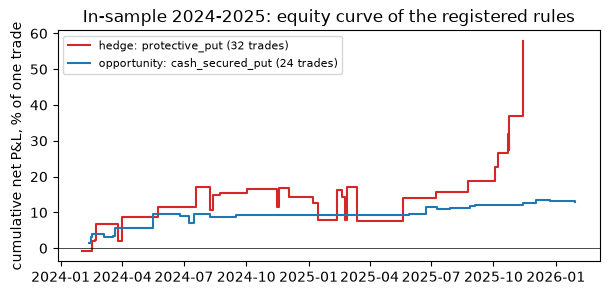

In [13]:
book_in, _ = book_report(study, 2.0, "In-sample 2024-2025")

**Reading, in-sample 2024–2025.** H1's protective put: 32 trades, +1.81% net a trade, Sharpe 1.20 net, max drawdown
−9.6% of one trade's notional, about 1.3 positions open at a time. The same put bought on ordinary days, at the same trade
rate and net of the same haircut, had a Sharpe of 1.01. H2's cash-secured put: 24 trades, +0.54% net, Sharpe 1.41 net, max
drawdown −2.8%, against 0.74 on ordinary days. Both books made money in 2024–25 mostly because puts on large caps in a
rising market did; the filing's own contribution is the edge over ordinary days, which the pass rule tests and which is
not distinguishable from zero.

## 8 · Out-of-sample, 2026-01-01 to 2026-08-31

The frozen pipeline, exits pinned to 2 October 2026 as in the single committed run (`results/oos/`).

events: 11 events -> 30 priced (event, bucket) pairs; 3 drops


placebo hedge: 120 events -> 318 priced (event, bucket) pairs; 38 drops


placebo opportunity: 120 events -> 303 priced (event, bucket) pairs; 53 drops


Out-of-sample window 2026-01-01 -> 2026-08-31; last session used for exits 2026-10-02 (pinned)

[hedge] out-of-sample verdict: INSUFFICIENT
[hedge] protective_put: events minus ordinary days at every fixed horizon (97.5% CI; n < 5 has no interval)


,strategy,horizon,n_a,n_b,mean_a,mean_b,difference,ci_lo,ci_hi,p_value
0,protective_put,1,3,111,NaN,NaN,NaN,NaN,NaN,NaN
1,protective_put,2,3,107,NaN,NaN,NaN,NaN,NaN,NaN
2,protective_put,3,3,106,NaN,NaN,NaN,NaN,NaN,NaN
3,protective_put,5,3,108,NaN,NaN,NaN,NaN,NaN,NaN
4,protective_put,10,3,110,NaN,NaN,NaN,NaN,NaN,NaN
5,protective_put,21,3,107,NaN,NaN,NaN,NaN,NaN,NaN
6,protective_put,42,3,81,NaN,NaN,NaN,NaN,NaN,NaN
7,protective_put,63,1,68,NaN,NaN,NaN,NaN,NaN,NaN
8,protective_put,exp,1,65,NaN,NaN,NaN,NaN,NaN,NaN


...

,n,mean_ratio,ci_lo,ci_hi,median_ratio,share_above_1
horizon,,,,,,
1,7,2.391101,0.969618,3.811192,1.759743,0.571429
2,7,2.500104,0.978192,3.946745,2.538692,0.571429
3,7,2.326583,1.066005,3.721904,1.809739,0.571429
5,7,2.155035,1.247924,3.255023,1.338322,0.714286
10,6,1.797824,0.780550,2.861237,1.627205,0.666667
21,6,1.569449,0.849871,2.300507,1.538893,0.666667
42,7,1.172257,0.666670,1.631670,1.329762,0.571429
63,5,0.624352,0.194697,1.117306,0.650196,0.200000
exp,6,0.791514,0.447795,1.189161,0.638417,0.333333


[opportunity] headline horizons: in-sample vs out-of-sample edge


,edge_in_sample,n_oos,edge_oos,same_sign
horizon,,,,
21,0.000899,7,-0.021458,False
42,0.002086,7,-0.013823,False
exp,0.009208,4,NaN,False


Out-of-sample Jan-Aug 2026: the book, net of a 5% premium haircut each way (percent of one trade's stock notional). Ordinary days are a 120-day sample per family, annualised at the filings' trade rate: compare Sharpe and mean, not trade count or drawdown.


trades  trades_per_year  mean_net_pct  hit_rate  \
family      series                                                           
hedge       filings             3              4.5          2.68      0.67   
            ordinary days     133              4.5          0.71      0.52   
opportunity filings             7             10.5         -2.82      0.43   
            ordinary days     102             10.5         -0.31      0.48   

                           annual_return_pct  annual_vol_pct  sharpe_net  \
family      series                                                         
hedge       filings                    12.07           17.09        0.71   
            ordinary days               3.18            9.45        0.34   
opportunity filings                   -29.59           21.77       -1.36   
            ordinary days              -3.22           12.90       -0.25   

                           max_drawdown_pct  worst_trade_pct  \
family      series                                             
hedge       filings                   -5.46            -5.46   
            ordinary days            -98.30            -6.89   
opportunity filings                  -25.31           -15.54   
            ordinary days            -57.23           -22.60   

                           avg_open_positions  turnover_x_per_year  
family      series                                                  
hedge       filings                      0.38                 12.0  
            ordinary days                0.38                 12.0  
opportunity filings                      0.88                 12.0  
            ordinary days                0.88                 12.0

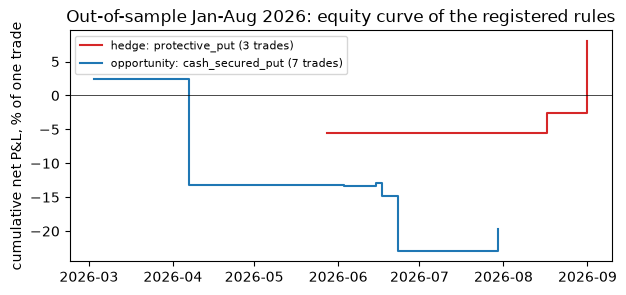

In [14]:
if RUN_OOS:
    OOS_LAST = pd.Timestamp(OOS_LAST_SESSION)
    oos = run_family_study(client, cal, cfg, cfg.oos_start, cfg.oos_end, OOS_LAST, user_agent=None, max_workers=MAX_WORKERS)
    print(f"Out-of-sample window {cfg.oos_start} -> {cfg.oos_end}; last session used for exits {OOS_LAST.date()} (pinned)")
    for fam in FAMILIES:
        chk = oos["checks"].get(fam)
        r_e, r_p = of_family(oos["results"], fam), of_family(oos["placebo_results"], fam)
        print(f"\n[{fam}] out-of-sample verdict: {verdict(chk)}")
        if len(r_e) and len(r_p):
            strat = chk["strategy"] if chk else None
            show(difference_board(r_e, r_p, cfg, level=cfg.confirmatory_level, strategies=[strat]),
                 f"[{fam}] {strat}: events minus ordinary days at every fixed horizon (97.5% CI; n < 5 has no interval)")
            show(decay_table(r_e, cfg), f"[{fam}] parity decay, out-of-sample events")
        ins = study["checks"].get(fam)
        if chk is not None and ins is not None:
            a = ins["pnl"][["horizon", "difference"]].rename(columns={"difference": "edge_in_sample"})
            b = chk["pnl"][["horizon", "n_a", "difference"]].rename(columns={"n_a": "n_oos", "difference": "edge_oos"})
            cmp_ = a.merge(b, on="horizon", how="left")
            cmp_["same_sign"] = np.sign(cmp_.edge_in_sample) == np.sign(cmp_.edge_oos)
            show(cmp_.set_index("horizon"), f"[{fam}] headline horizons: in-sample vs out-of-sample edge")
    book_report(oos, 8 / 12, "Out-of-sample Jan-Aug 2026")
else:
    print("Out-of-sample not run (RUN_OOS = False). The committed single run is in results/oos/SUMMARY.md.")

**Reading, out-of-sample January–August 2026.** H1 is **INSUFFICIENT** (3 events). H2 is **NULL with its sign reversed**:
−2.15% [−7.59, +2.03] at 21 sessions and −1.38% at 42, against +0.09% and +0.21% in-sample. The decay table shows why:
in 2026 restructuring filings moved 2.2 to 2.5 times the implied move in the first week (interval above 1 at 3 and 5
sessions, 7 events). That is the one place the ruler visibly bent, and it bent the opposite way to H2: the chain
under-priced the first week. Our forecast had "no pass" and the H2 count right, and missed the H1 count, the interval
widths and all three signs it could score.

## 9 · A fresh year: 2022, run once (S27)

Pre-registered in `s27_liquid_8k/METHOD.md` (commit `41a04a6`) before any 2022 event or option price was pulled, and run once.
The frozen pipeline (same tags, timing and pass rule) on a year no study had used. The registered primary, a cut to the most
liquid option names, left 3 H1 and 1 H2 events (INSUFFICIENT); this section shows the full-year replication, which was
registered as its secondary analysis. The decomposition at the end splits the protective put into its stock and its put.

events: 27 events -> 74 priced (event, bucket) pairs; 7 drops


placebo hedge: 120 events -> 312 priced (event, bucket) pairs; 44 drops


placebo opportunity: 120 events -> 311 priced (event, bucket) pairs; 41 drops



[hedge] 2022 verdict: NULL; pass conditions met at: [21]
[hedge] protective_put: events minus ordinary days at every fixed horizon, 2022 (97.5% CI)


,strategy,horizon,n_a,n_b,mean_a,mean_b,difference,ci_lo,ci_hi,p_value
0,protective_put,1,11,101,-0.000120,-0.002587,0.002467,-0.003654,0.008304,0.3730
1,protective_put,2,12,98,0.003346,-0.005454,0.008800,-0.001346,0.018770,0.0520
2,protective_put,3,12,96,0.004372,-0.004142,0.008514,-0.005867,0.021935,0.1800
3,protective_put,5,12,100,0.002718,-0.005456,0.008174,-0.006691,0.022825,0.2205
4,protective_put,10,12,97,0.020720,-0.002474,0.023194,-0.004822,0.053377,0.0710
5,protective_put,21,12,90,0.042819,-0.000222,0.043042,0.005430,0.079331,0.0105
6,protective_put,42,12,89,0.023932,0.016027,0.007905,-0.035060,0.055152,0.7055
7,protective_put,63,11,82,0.009558,0.006282,0.003276,-0.062886,0.091258,0.9975
8,protective_put,exp,11,90,0.019053,0.003644,0.015409,-0.063338,0.116119,0.7610


...

,strategy,horizon,n_a,n_b,mean_a,mean_b,difference,ci_lo,ci_hi,p_value
0,cash_secured_put,1,12,108,-0.001955,-0.002020,0.000066,-0.005540,0.004953,0.9485
1,cash_secured_put,2,12,107,-0.003625,-0.001894,-0.001732,-0.007997,0.004083,0.5000
2,cash_secured_put,3,12,108,-0.001314,-0.001684,0.000370,-0.004639,0.005654,0.8790
3,cash_secured_put,5,12,108,-0.000112,-0.001995,0.001883,-0.003733,0.007059,0.4035
4,cash_secured_put,10,11,106,0.004078,-0.003840,0.007918,-0.004124,0.018941,0.1405
5,cash_secured_put,21,12,106,0.002881,-0.001879,0.004759,-0.017166,0.022238,0.5600
6,cash_secured_put,42,12,106,0.005315,0.003683,0.001631,-0.025096,0.022964,0.8705
7,cash_secured_put,63,12,104,0.013052,0.005373,0.007679,-0.037284,0.035390,0.5890
8,cash_secured_put,exp,11,102,-0.004592,0.006020,-0.010612,-0.052566,0.023955,0.5685


H1 in 2022, decomposed: where the protective put's gain came from


,filings,ordinary days
"stock return, 21 sessions",0.0612,0.0063
share of stocks that fell,0.2500,0.3925
put leg alone,-0.0184,-0.0005
protective put,0.0428,-0.0002


Fresh year 2022: the book, net of a 5% premium haircut each way (percent of one trade's stock notional). Ordinary days are a 120-day sample per family, annualised at the filings' trade rate: compare Sharpe and mean, not trade count or drawdown.


trades  trades_per_year  mean_net_pct  hit_rate  \
family      series                                                           
hedge       filings            12             12.0          3.85      0.75   
            ordinary days      92             12.0         -0.31      0.50   
opportunity filings            12             12.0         -0.12      0.50   
            ordinary days     110             12.0         -0.61      0.48   

                           annual_return_pct  annual_vol_pct  sharpe_net  \
family      series                                                         
hedge       filings                    46.23           19.81        2.33   
            ordinary days              -3.72           19.36       -0.19   
opportunity filings                    -1.40           10.58       -0.13   
            ordinary days              -7.34            8.36       -0.88   

                           max_drawdown_pct  worst_trade_pct  \
family      series                                             
hedge       filings                   -8.23            -5.42   
            ordinary days           -120.20           -13.42   
opportunity filings                  -12.07            -8.15   
            ordinary days            -80.93           -10.00   

                           avg_open_positions  turnover_x_per_year  
family      series                                                  
hedge       filings                       1.0                 12.0  
            ordinary days                 1.0                 12.0  
opportunity filings                       1.0                 12.0  
            ordinary days                 1.0                 12.0

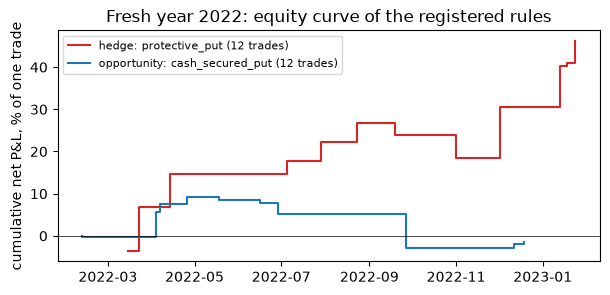

In [15]:
fresh = None if not RUN_FRESH_2022 else run_family_study(client, cal, cfg, "2022-01-01", "2022-12-31", pd.Timestamp("2026-10-02"), user_agent=None, max_workers=MAX_WORKERS)
for fam in (FAMILIES if fresh is not None else []):
    chk = fresh["checks"].get(fam)
    r_e, r_p = of_family(fresh["results"], fam), of_family(fresh["placebo_results"], fam)
    print(f"\n[{fam}] 2022 verdict: {verdict(chk)}; pass conditions met at: {sorted(set(chk['horizons_pnl_ok']) & set(chk['horizons_ratio_ok']), key=str) if chk else []}")
    if len(r_e) and len(r_p):
        show(difference_board(r_e, r_p, cfg, level=cfg.confirmatory_level, strategies=[chk["strategy"]]),
             f"[{fam}] {chk['strategy']}: events minus ordinary days at every fixed horizon, 2022 (97.5% CI)")
if fresh is None:
    print("2022 fresh year not run (RUN_FRESH_2022 = False); the committed run is in results/s27_liquid_8k/.")
h1 = lambda d: d[(d.family == "hedge") & (d.bucket == cfg.baseline_bucket) & (d.entry == "post") & (d.otm == cfg.otm_pct) & (d.horizon == 21)]
if fresh is not None:
  ev, pl = h1(fresh["results"]), h1(fresh["placebo_results"])
  show(pd.DataFrame({"filings": [ev.realized.mean(), (ev.realized < 0).mean(), (ev.protective_put - ev.stock).mean(), ev.protective_put.mean()],
                   "ordinary days": [pl.realized.mean(), (pl.realized < 0).mean(), (pl.protective_put - pl.stock).mean(), pl.protective_put.mean()]},
                  index=["stock return, 21 sessions", "share of stocks that fell", "put leg alone", "protective put"]).round(4),
     "H1 in 2022, decomposed: where the protective put's gain came from")
  book_report(fresh, 1.0, "Fresh year 2022")

**Reading.** On a fresh year, H1 met both pass conditions at 21 sessions: +4.30% over ordinary days [+0.54, +7.93] on 12
events, Sharpe 2.57 against −0.04 for the same put on ordinary days. It did not at 42 sessions or expiry, so the verdict is
NULL. The decomposition shows the gain is not H1's mechanism: after the bad news the stocks rose 6.1% in 21 sessions (only a
quarter fell) against 0.6% on ordinary days, while the put alone lost 1.8%. In a falling market the headline was oversold
and the put dear; the protective put earned through the stock it owns. That is a lead for a test of post-filing rebounds in
stress regimes. H2 in 2022 is NULL: +0.48% at 21 sessions [−1.72, +2.22].

## 10 · H3: sell the put after bad-news filings (discovered on 2022)

Section 9's decomposition points at a different trade. In stress, bad news is oversold and puts are dear, so the trade
paid by both is to **sell** the put: after an H1 filing (the 7 frozen tags), sell the 5%-out-of-the-money 3–6 month put
at the close of the session after the filing (conservative timing), cash-secured, and hold it. The put seller is paid by
the rebound and by the premium. Edge = the same trade on ordinary days of the same companies; PASS if the 97.5% interval
lies above zero at 2 or more of 21 sessions, 42 sessions and expiry. **High fear**: the event's implied move at entry is
at least 14%, applied to events and ordinary days alike; all H1 events are reported as the secondary scope.

The rule was committed in `s28_sell_fear/METHOD.md` (commit `f9468bf`) before the high-fear filter touched any window.
**2022 formed the hypothesis, so its numbers are not evidence for it.** The confirmatory test is the sealed window below.

In [16]:
import sys
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
try:
    from s28_sell_fear.run import high_fear, h3
except ImportError:
    high_fear = h3 = None
    print("s28_sell_fear not found (notebook opened outside the repo); the committed H3 run is in results/s28_sell_fear/SUMMARY.md.")


def h3_rows(st, years, window):
    ev, pl = of_family(st["results"], "hedge"), of_family(st["placebo_results"], "hedge")
    rows = []
    for scope in ("all H1", "high fear"):
        a, b = (ev, pl) if scope == "all H1" or not len(ev) or not len(pl) else (high_fear(ev), high_fear(pl))
        d, v, ok, n, s_ev, s_pl = h3(a, b, cfg, years)
        row = {"window": window, "scope": scope, "verdict": v, "events_21": n}
        for hz in (21, 42):
            x = d[d.horizon == hz] if len(d) else d
            if not len(x) or pd.isna(x.difference.iloc[0]):
                row[f"edge_{hz}"] = "too few events"
            elif pd.isna(x.ci_lo.iloc[0]):
                row[f"edge_{hz}"] = f"{100 * x.difference.iloc[0]:+.2f}% (no interval)"
            else:
                row[f"edge_{hz}"] = f"{100 * x.difference.iloc[0]:+.2f}% [{100 * x.ci_lo.iloc[0]:+.2f}, {100 * x.ci_hi.iloc[0]:+.2f}]"
        row["sharpe_21_events_vs_ordinary"] = f"{s_ev:.2f} vs {s_pl:.2f}"
        rows.append(row)
    return rows


if h3 is not None:
    if fresh is None:
        print("2022 not run (RUN_FRESH_2022 = False); showing 2024-25 and 2026 only. The committed 2022 run is in results/s28_sell_fear/.")
    h3_tab = []
    for st, yrs, name in ((fresh, 1.0, "2022 (discovery)"), (study, 2.0, "2024-25 (seen)"),
                          (globals().get("oos") if RUN_OOS else None, 8 / 12, "2026 (seen)")):
        if st is not None:
            h3_tab += h3_rows(st, yrs, name)
    h3_tab = pd.DataFrame(h3_tab)
    with pd.option_context("display.width", 200, "display.max_colwidth", 40):
        print("H3: cash-secured put after H1 filings minus ordinary days (97.5% CI; Sharpe at 21 sessions, annualised)")
        print(h3_tab.to_string(index=False))

H3: cash-secured put after H1 filings minus ordinary days (97.5% CI; Sharpe at 21 sessions, annualised)
          window     scope      verdict  events_21               edge_21               edge_42 sharpe_21_events_vs_ordinary
2022 (discovery)    all H1         PASS         12 +1.73% [+0.33, +3.11] +2.25% [+0.51, +4.06]                 3.34 vs 0.11
2022 (discovery) high fear         PASS          7 +2.17% [+0.28, +3.83] +2.63% [+0.37, +4.88]                 3.56 vs 0.29
  2024-25 (seen)    all H1         NULL         33 +0.03% [-1.17, +1.12] -0.18% [-1.76, +1.43]                 0.57 vs 0.51
  2024-25 (seen) high fear         NULL          8 -1.38% [-5.61, +2.02] -2.12% [-7.27, +2.37]                -0.07 vs 0.69
     2026 (seen)    all H1 INSUFFICIENT          3        too few events        too few events                 0.41 vs 0.30
     2026 (seen) high fear INSUFFICIENT          1        too few events        too few events                  nan vs 0.70


**Reading.** On 2022, where H3 was discovered, it shows the pass shape: all 12 H1 events +1.73% [+0.33, +3.11] at 21
sessions and +2.25% [+0.51, +4.06] at 42, Sharpe 3.34 against 0.11 on ordinary days; the 7 high-fear events +2.17% and
+2.63%, Sharpe 3.56. That is the discovery, not evidence. On 2024–25 (seen, calm) H3 is **NULL**: all H1 +0.03% at 21
sessions, and high fear −1.38% [−5.61, +2.02] on 8 events. **The stock-level fear filter failed**: high-fear filings in a
calm market did not rebound. What separated 2022 looks like market-wide stress, and that condition has not been defined or
tested; no condition is added after the fact. 2026 is INSUFFICIENT (1 and 3 events). The sealed window is H3's
confirmatory test.

2023 out-of-sample: see results/s28_sell_fear/oos_2023-01-01_2023-12-31.json

## Sealed window · judges only

Set `HOLDOUT_START`, `HOLDOUT_END` and `RUN_HOLDOUT = True` in the configuration cell and run all cells. This cell runs
the frozen pipeline (same tags, same pass rule, same conservative timing) on that window for both families. Horizons that
have not resolved by today are absent rather than guessed.

**What we predicted** ([FORECAST.md](FORECAST.md), committed before any window outside 2024–2025 was run): a 3-month window
gives about 4 H1 and 3 H2 events, too few for an interval, so INSUFFICIENT for both; 4–5 months NULL or INSUFFICIENT;
6 months or more NULL for both. A PASS would contradict the forecast and we would call it a surprise, not a confirmation.

**H3 is tested here too** (section 10, rule committed in `s28_sell_fear/METHOD.md`, `f9468bf`): the cash-secured put
after H1 filings, high-fear events and all H1 events, against ordinary days. This is its first confirmatory test.
Forecast: a calm window gives few high-fear events and a null (or INSUFFICIENT); a stressed window should show the edge at
21 and 42 sessions.

In [17]:
FORECAST = [(3.5, "INSUFFICIENT", "INSUFFICIENT"), (5.5, "NULL or INSUFFICIENT", "INSUFFICIENT"),
            (12.5, "NULL", "NULL"), (float("inf"), "NULL", "NULL")]


def forecast_for(start, end):
    months = (pd.Timestamp(end) - pd.Timestamp(start)).days / 30.44
    h1, h2 = next((a, b) for m, a, b in FORECAST if months <= m)
    return months, {"hedge": h1, "opportunity": h2}


if RUN_HOLDOUT:
    LAST_H = cal.last_completed()
    holdout = run_family_study(client, cal, cfg, HOLDOUT_START, HOLDOUT_END, LAST_H, user_agent=None, max_workers=MAX_WORKERS)
    months, fc = forecast_for(HOLDOUT_START, HOLDOUT_END)
    print(f"Sealed window {HOLDOUT_START} -> {HOLDOUT_END} ({months:.1f} months); exits up to {LAST_H.date()}")
    rows = []
    for fam in FAMILIES:
        chk = holdout["checks"].get(fam)
        r_e, r_p = of_family(holdout["results"], fam), of_family(holdout["placebo_results"], fam)
        sb = scoreboard(r_e, cfg, strategies=["stock"], horizons=[21]) if len(r_e) else None
        n_ev = int(sb["n"].sum()) if sb is not None and len(sb) else 0
        rows.append({"family": fam, "events_at_21": n_ev, "verdict": verdict(chk), "our_forecast": fc[fam]})
        if len(r_e) and len(r_p):
            strat = chk["strategy"] if chk else None
            show(difference_board(r_e, r_p, cfg, level=cfg.confirmatory_level, strategies=[strat]),
                 f"[{fam}] {strat}: events minus ordinary days at every fixed horizon (97.5% CI)")
            show(scoreboard(r_e, cfg), f"[{fam}] all five strategies, events (95% CI)")
            de = decay_table(r_e, cfg)
            show(de, f"[{fam}] parity decay, sealed-window events")
            de_in = decay[fam][0]
            if len(de) and len(de_in):
                fig, ax = plt.subplots(figsize=(6, 3.2))
                order = [*cfg.horizons, "exp"]
                for tbl, label, colr in ((de_in, "in-sample events", "tab:red"), (de, "sealed-window events", "tab:green"),
                                         (decay[fam][1], "in-sample ordinary days", "tab:gray")):
                    t = tbl.dropna(subset=["mean_ratio"])
                    ax.plot([order.index(h) for h in t.index], t["mean_ratio"], "o-", label=label, color=colr)
                ax.axhline(1, color="k", lw=0.6)
                ax.set_xticks(range(len(order)), [str(h) for h in order])
                ax.set_xlabel("sessions after the filing"); ax.set_ylabel("|realized| / implied")
                ax.set_title(f"[{fam}] parity decay"); ax.legend(fontsize=8)
                plt.show()
        else:
            print(f"[{fam}] no priced events or no placebo in this window")
    if h3 is not None:
        h3_hold = pd.DataFrame(h3_rows(holdout, months / 12, f"sealed {HOLDOUT_START}..{HOLDOUT_END}"))
        with pd.option_context("display.width", 200, "display.max_colwidth", 40):
            print("H3 on the sealed window: cash-secured put after H1 filings minus ordinary days (97.5% CI)")
            print(h3_hold.to_string(index=False))
        for r in h3_hold.to_dict("records"):
            rows.append({"family": f"H3 {r['scope']} (cash_secured_put)", "events_at_21": r["events_21"], "verdict": r["verdict"],
                         "our_forecast": "NULL or INSUFFICIENT if calm; edge at 21 and 42 if stressed"})
    show(pd.DataFrame(rows).set_index("family"), "Sealed window: verdict against our committed forecast")
    book_report(holdout, months / 12, f"Sealed window {HOLDOUT_START} to {HOLDOUT_END}")
else:
    print(f"Sealed window {HOLDOUT_START}..{HOLDOUT_END} not run. Judges: set RUN_HOLDOUT = True.")

Sealed window 2023-06-01..2023-08-31 not run. Judges: set RUN_HOLDOUT = True.


## What this says about the thesis

**The ruler held, and one fresh year shows where it slips.** On 2022, run once, H1 beat ordinary days by +4.30% at
21 sessions [+0.54, +7.93], meeting both pass conditions at that horizon, though the gain came from stocks rebounding after
the news rather than from cheap puts (section 9). Otherwise the option chain at the 100 largest US stocks priced the move
about right: within roughly 3% of the stock price for post-headline protection and 0.9% for restructuring
puts over 2024–2025, and too few or too noisy events since. The mechanisms left traces in the right direction (H1's decay
shape, H2's stable sensitivity sign), but not edges a desk could trade after costs and at this capacity.
H3 is the conditional trade (sell the put after bad-news filings in market stress): discovered on 2022 with Sharpe 3.34,
flat in calm 2024–25, and tested independently on the sealed window.

That is the result PolyBridge's premise needs. We use the chain as the reference price for thinner markets, and this study
finds no headline-driven bend large enough to matter. The one bend we saw, restructurings in 2026 moving far more than
priced in their first week, is the next pre-registered test, together with `restructuring_plan` alone and H2 entry a few
sessions after the filing, on a window with the power to detect a 0.5% edge.

## Known limitations

- **Static universe.** `TOP_100` is today's list applied to the whole window: a survivorship bias.
- **Spot is inferred.** The stock price comes from put-call parity on the ATM pair with a flat carry rate and no dividend term; both legs are last trades and can be stale. The error largely cancels in P&L because entry and exit use the same construction.
- **The synthetic stock is not shares.** It collects no dividends and its short put can be assigned early; neither is modelled.
- **Last-trade marks, no spreads.** P&L is theoretical, mid-market at best. The cost section applies a 5% premium haircut (1x and 2x) and real half-spreads where quotes exist.
- **Small samples.** Intervals are wide; read the `n` columns before the means.
- **No earnings flag.** Events that share their window with an earnings release are not separated.
- **Filing lag and time of day.** `filing_date` has no time of day. **Every filing is treated as public after the close** (the next session is `t_0`): conservative, no lookahead, and slightly late for pre-market filings. EDGAR acceptance times are not used in the confirmatory path (the conservative rule is frozen; EDGAR's fixed 16:00 cutoff also mishandles 13:00 early closes).
- **Pre-event reference under conservative timing.** `t_pre` is the filing day itself, which may already contain intraday news for filings made during market hours.
- **Bootstrap.** The pass rule uses the pre-registered iid bootstrap. The robustness cell also resamples whole companies, which allows for same-company clustering; neither interval accounts for overlapping holding windows across companies.
- **Multi-ticker filings** keep the first in-universe ticker.
- **Run date and cache.** The client caches bar responses for unexpired contracts, so a cache built on one run date must not be treated as complete on a later date. Pin `LAST_SESSION` at the freeze and run the out-of-sample window once.
- **Strike availability.** When no strike sits at the requested OTM distance, the nearest listed one is used.
- **Exploratory material** (the atlas, off by default) shares one placebo across tags and never replaces H1 or H2.
